In [1]:

import re
import ssl
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer, word_tokenize

try:
    _create_unverified_https_context = ssl._create_unverified_context
    ssl._create_default_https_context = _create_unverified_https_context
except AttributeError:
    pass
#ako su potrebne instalacije 
#nltk.download("stopwords")
#nltk.download("wordnet")


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import clone


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.decomposition import TruncatedSVD


from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)


import joblib

In [2]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

In [3]:
data=pd.read_csv('../../Reviews.csv')
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
data_small, _ = train_test_split(
    data,
    train_size=50000,
    stratify=data["Score"],
    random_state=42
)
data_small["Score"].value_counts()

Score
5    31940
4     7094
1     4597
3     3751
2     2618
Name: count, dtype: int64

In [5]:
data_sent = data_small[data_small['Score'] != 3].copy()

data_sent['Sentiment'] = data_sent['Score'].apply(lambda x: 'positive' if x > 3 else 'negative')
data_sent["Sentiment"] = data_sent["Sentiment"].apply(lambda x: 1 if x == 'positive' else 0)

In [6]:
data_sent["TextFull"] = data_sent["Summary"].fillna("") + " " + data_sent["Text"].fillna("")
data_sent["HelpfulnessRatio"] = data_sent["HelpfulnessNumerator"] / (data_sent["HelpfulnessDenominator"] + 1e-9)


In [7]:
data_sent["cleaned_full"] = data_sent["TextFull"].apply(clean_text)
num_cols = ["HelpfulnessNumerator", "HelpfulnessDenominator", "HelpfulnessRatio"]
text_col = "cleaned_full"


In [8]:
data_sent.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,TextFull,HelpfulnessRatio,cleaned_full
377432,377433,B001AML2LI,AK3SUUL1WSM7G,"carobonly ""rosered""",3,5,4,1190592000,good for 100 calories,"Not bad for being only 100 calories, crispy an...",1,good for 100 calories Not bad for being only 1...,0.6,good calorie bad calorie crispy crunchy defini...
357755,357756,B001GCTTRQ,A333ABL4WW067D,Brandy,0,0,1,1332374400,Fish tea,"I know nettle tea has a pretty distinct taste,...",0,Fish tea I know nettle tea has a pretty distin...,0.0,fish tea know nettle tea pretty distinct taste...
483229,483230,B00282QG6U,A2H7FG21UZLYR4,Amazon Prime Member,0,0,5,1350345600,Great Stuff here,I have ordered all kinds of SweetLeaf Stevia p...,1,Great Stuff here I have ordered all kinds of S...,0.0,great stuff ordered kind sweetleaf stevia prod...
98424,98425,B004GW6O9E,A3VFNQBW7VY938,Isabelle Rowe,0,0,5,1336694400,Wonderful taste. Love these bars,This was the first time I purchased this flavo...,1,Wonderful taste. Love these bars This was the ...,0.0,wonderful taste love bar first time purchased ...
106314,106315,B001QZZ1J8,A2DWNAHNLA7NK7,V. Kneifl,5,5,5,1264204800,Best cornbread I've ever tasted!,"For years, I've been looking for cornbread lik...",1,"Best cornbread I've ever tasted! For years, I'...",1.0,best cornbread ever tasted year looking cornbr...


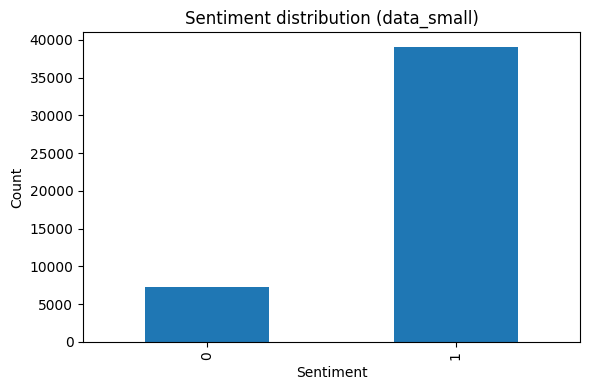

In [9]:
plt.figure(figsize=(6,4))
data_sent["Sentiment"].value_counts().sort_index().plot(kind="bar")
plt.title("Sentiment distribution (data_small)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

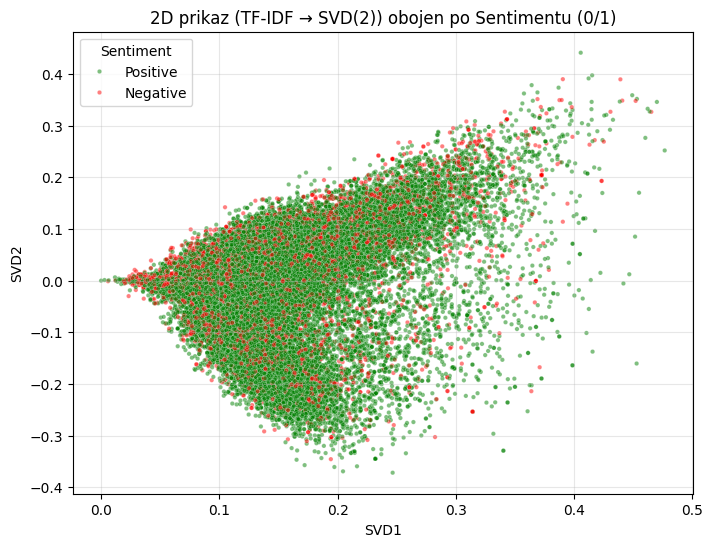

In [10]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=2)
X_t = tfidf.fit_transform(data_sent["cleaned_full"])

svd2 = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd2.fit_transform(X_t)

viz_df = pd.DataFrame({
    "SVD1": X_2d[:,0],
    "SVD2": X_2d[:,1],
    "Sentiment": data_sent['Sentiment']  # 0 ili 1
})

viz_df["SentimentLabel"] = viz_df["Sentiment"].map({
    0: "Negative",
    1: "Positive"
})

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=viz_df,
    x="SVD1",
    y="SVD2",
    hue="SentimentLabel",
    palette={
        "Negative": "red",
        "Positive": "green"
    },
    alpha=0.5,
    s=10
)

plt.title("2D prikaz (TF-IDF → SVD(2)) obojen po Sentimentu (0/1)")
plt.legend(title="Sentiment")
plt.grid(alpha=0.3)
plt.show()

In [11]:
X = data_sent[["cleaned_full", "HelpfulnessNumerator", "HelpfulnessDenominator", "HelpfulnessRatio"]]
y = data_sent["Sentiment"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [12]:
train_df = X_train.copy()
train_df["Sentiment"] = y_train.values

min_count = train_df["Sentiment"].value_counts().min()

train_bal = (
    train_df.groupby("Sentiment", group_keys=False)
    .apply(lambda g: g.sample(min_count, random_state=42))
)

X_train_bal = train_bal.drop(columns=["Sentiment"])
y_train_bal = train_bal["Sentiment"]

In [13]:

def make_preprocessor(max_features=20000):
    tfidf = TfidfVectorizer(max_features=max_features, ngram_range=(1,2), min_df=2)
    return ColumnTransformer(
        transformers=[
            ("text", Pipeline([("tfidf", tfidf)]), text_col),
            ("num", MaxAbsScaler(), num_cols)
        ],
        remainder="drop"
    )

In [14]:
models = {
    "LinearSVC": LinearSVC(dual="auto", max_iter=5000),
    "SGD hinge": SGDClassifier(loss="hinge", random_state=42),
    "LogReg": LogisticRegression(max_iter=500, n_jobs=-1),
    "Random forest": RandomForestClassifier(n_estimators=300,max_depth=30,max_features="sqrt",min_samples_split=5,n_jobs=-1,
    random_state=42),
    "ComplementNB": ComplementNB(),
}

def run_block(Xtr, Xte, ytr, yte, dataset_label, max_features):
    pre = make_preprocessor(max_features=max_features)
    rows = []
    
    
    print(f"\n=== Dataset: {dataset_label} | TFIDF: {max_features} ===")
    
    for i, (name, model) in enumerate(models.items(), 1):
        print(f" Trening modela: {name} ...", end=" ")
        
        pipe = Pipeline([("pre", pre), ("clf", clone(model))])
        pipe.fit(Xtr, ytr)
        pred = pipe.predict(Xte)
        
        acc = accuracy_score(yte, pred)
        f1m = f1_score(yte, pred, average="macro")
        f1w = f1_score(yte, pred, average="weighted")
        
        print(f"done | Acc={acc:.4f} | F1_macro={f1m:.4f} | F1_weighted={f1w:.4f}")
        
        rows.append({
            "Dataset": dataset_label,
            "TFIDF": f"{max_features}",
            "Model": name,
            "Accuracy": acc,
            "F1_macro": f1m,
            "F1_weighted": f1w
        })
        
    return rows

In [15]:
rows = []
for k in [10000, 20000]:
    rows += run_block(X_train, X_test, y_train, y_test, "RAW", k)
    rows += run_block(X_train_bal, X_test, y_train_bal, y_test, "BAL", k)

results_df = pd.DataFrame(rows).sort_values("F1_macro", ascending=False)
results_df


=== Dataset: RAW | TFIDF: 10000 ===
 Trening modela: LinearSVC ... done | Acc=0.9391 | F1_macro=0.8783 | F1_weighted=0.9375
 Trening modela: SGD hinge ... done | Acc=0.9261 | F1_macro=0.8338 | F1_weighted=0.9190
 Trening modela: LogReg ... done | Acc=0.9282 | F1_macro=0.8419 | F1_weighted=0.9223
 Trening modela: Random forest ... done | Acc=0.8622 | F1_macro=0.5675 | F1_weighted=0.8131
 Trening modela: ComplementNB ... done | Acc=0.8979 | F1_macro=0.8305 | F1_weighted=0.9041

=== Dataset: BAL | TFIDF: 10000 ===
 Trening modela: LinearSVC ... done | Acc=0.9012 | F1_macro=0.8397 | F1_weighted=0.9080
 Trening modela: SGD hinge ... done | Acc=0.9028 | F1_macro=0.8420 | F1_weighted=0.9094
 Trening modela: LogReg ... done | Acc=0.8922 | F1_macro=0.8276 | F1_weighted=0.9002
 Trening modela: Random forest ... done | Acc=0.8814 | F1_macro=0.8119 | F1_weighted=0.8906
 Trening modela: ComplementNB ... done | Acc=0.8959 | F1_macro=0.8294 | F1_weighted=0.9027

=== Dataset: RAW | TFIDF: 20000 ===
 

,Dataset,TFIDF,Model,Accuracy,F1_macro,F1_weighted
10,RAW,20000,LinearSVC,0.939676,0.879008,0.937953
0,RAW,10000,LinearSVC,0.939135,0.878335,0.937508
14,RAW,20000,ComplementNB,0.920216,0.853272,0.921459
16,BAL,20000,SGD hinge,0.910378,0.849780,0.915422
15,BAL,20000,LinearSVC,0.905946,0.846377,0.912192
6,BAL,10000,SGD hinge,0.902811,0.841985,0.909435
2,RAW,10000,LogReg,0.928216,0.841941,0.922283
5,BAL,10000,LinearSVC,0.901189,0.839663,0.907997
12,RAW,20000,LogReg,0.927351,0.837980,0.920769
1,RAW,10000,SGD hinge,0.926054,0.833775,0.918984


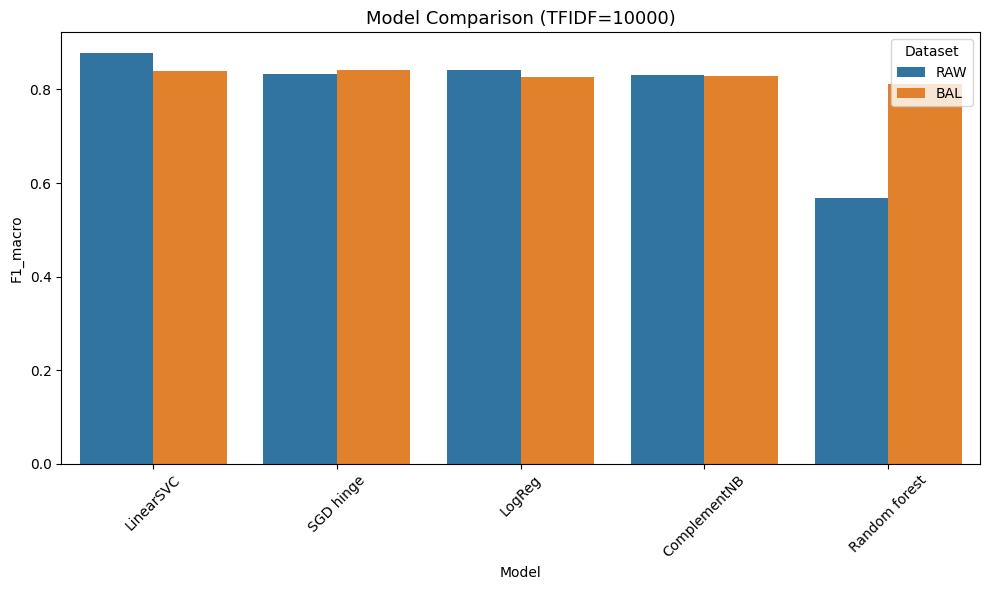

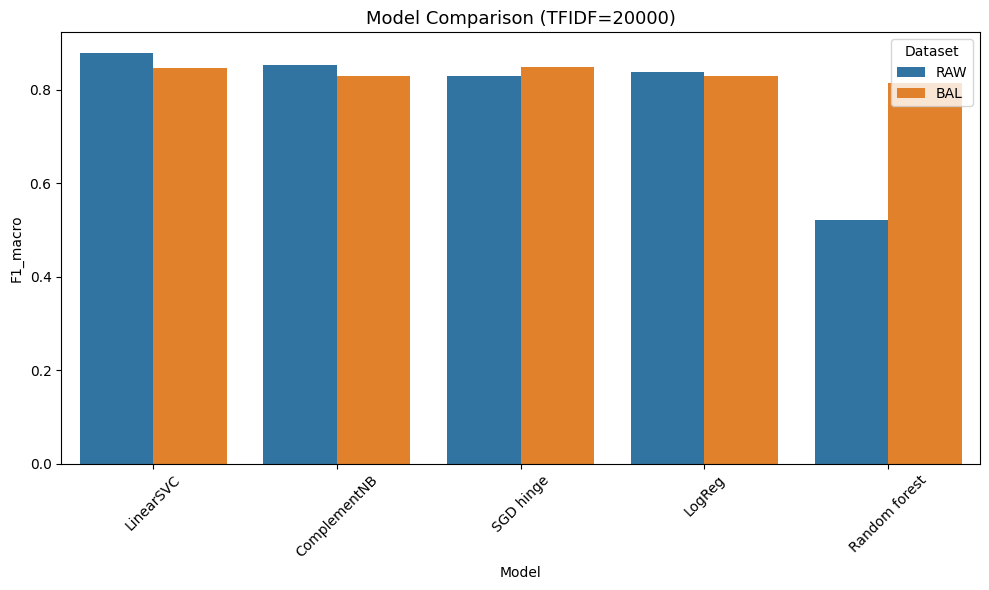

In [16]:
for tfidf_name in ["10000", "20000"]:
    plt.figure(figsize=(10,6))
    
    sub = results_df[results_df["TFIDF"] == tfidf_name]
    
    sns.barplot(
        data=sub,
        x="Model",
        y="F1_macro",
        hue="Dataset",
    )
    
    plt.xticks(rotation=45)
    plt.title(f"Model Comparison (TFIDF={tfidf_name})", fontsize=13)
    plt.tight_layout()
    plt.show()

In [17]:
def show_cm_raw_vs_bal_for_model(
    model_name,
    max_features,
    X_train, y_train,
    X_train_bal, y_train_bal,
    X_test, y_test,
    title_prefix="SCORE",
    normalize="true"

):
    
    pre = make_preprocessor(max_features=max_features)

    print("="*90)
    print(f"{title_prefix} | Model: {model_name} | TFIDF: {max_features}")
    print("="*90)

    pipe_raw = Pipeline([("pre", pre), ("clf", clone(models[model_name]))])
    pipe_raw.fit(X_train, y_train)

    pred_raw_tr = pipe_raw.predict(X_train)
    pred_raw_te = pipe_raw.predict(X_test)

    cm_raw_tr = confusion_matrix(y_train, pred_raw_tr, normalize=normalize)
    cm_raw_te = confusion_matrix(y_test,  pred_raw_te, normalize=normalize)

    # --- BAL ---
    pipe_bal = Pipeline([("pre", pre), ("clf", clone(models[model_name]))])
    pipe_bal.fit(X_train_bal, y_train_bal)

    pred_bal_tr = pipe_bal.predict(X_train_bal)
    pred_bal_te = pipe_bal.predict(X_test)

    cm_bal_tr = confusion_matrix(y_train_bal, pred_bal_tr,  normalize=normalize)
    cm_bal_te = confusion_matrix(y_test,      pred_bal_te,  normalize=normalize)

    # --- Plot 2x2 ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    ConfusionMatrixDisplay(cm_raw_tr).plot(ax=axes[0,0], cmap="Blues", colorbar=False)
    axes[0,0].set_title("RAW | TRAIN")
    axes[0,0].grid(False)

    ConfusionMatrixDisplay(cm_raw_te).plot(ax=axes[0,1], cmap="Blues", colorbar=False)
    axes[0,1].set_title("RAW | TEST")
    axes[0,1].grid(False)

    ConfusionMatrixDisplay(cm_bal_tr).plot(ax=axes[1,0], cmap="Blues", colorbar=False)
    axes[1,0].set_title("BAL | TRAIN")
    axes[1,0].grid(False)

    ConfusionMatrixDisplay(cm_bal_te).plot(ax=axes[1,1], cmap="Blues", colorbar=False)
    axes[1,1].set_title("BAL | TEST")
    axes[1,1].grid(False)

    plt.suptitle(f"{title_prefix}: {model_name} | TFIDF {max_features}", fontsize=14)
    plt.tight_layout()
    plt.show()

    # --- Reports ---
    print("\n--- RAW | TRAIN report ---")
    print(classification_report(y_train, pred_raw_tr))

    print("\n--- RAW | TEST report ---")
    print(classification_report(y_test, pred_raw_te))

    print("\n--- BAL | TRAIN report ---")
    print(classification_report(y_train_bal, pred_bal_tr))

    print("\n--- BAL | TEST report ---")
    print(classification_report(y_test, pred_bal_te))

Sentiment | Model: LinearSVC | TFIDF: 20000


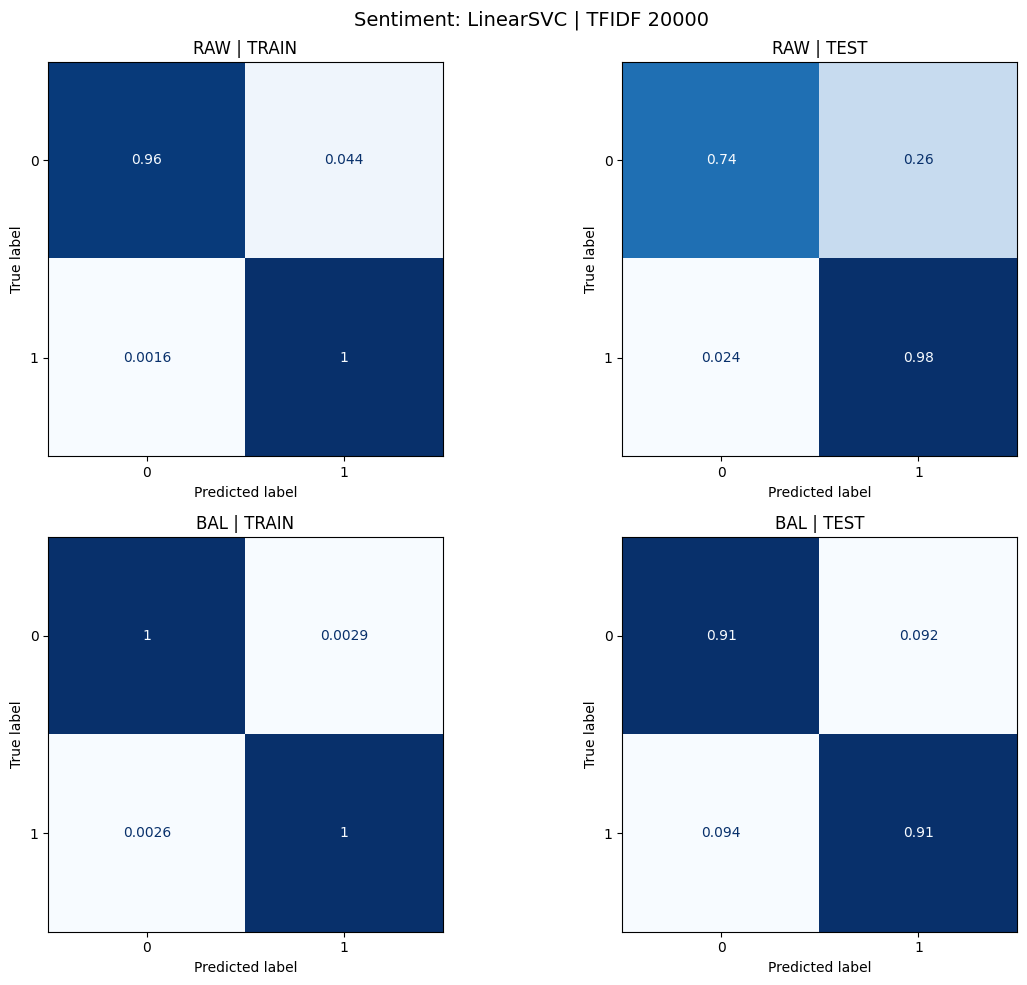


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           0       0.99      0.96      0.97      5772
           1       0.99      1.00      1.00     31227

    accuracy                           0.99     36999
   macro avg       0.99      0.98      0.98     36999
weighted avg       0.99      0.99      0.99     36999


--- RAW | TEST report ---
              precision    recall  f1-score   support

           0       0.85      0.74      0.79      1443
           1       0.95      0.98      0.96      7807

    accuracy                           0.94      9250
   macro avg       0.90      0.86      0.88      9250
weighted avg       0.94      0.94      0.94      9250


--- BAL | TRAIN report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5772
           1       1.00      1.00      1.00      5772

    accuracy                           1.00     11544
   macro avg       1.00      1.00      1.00  

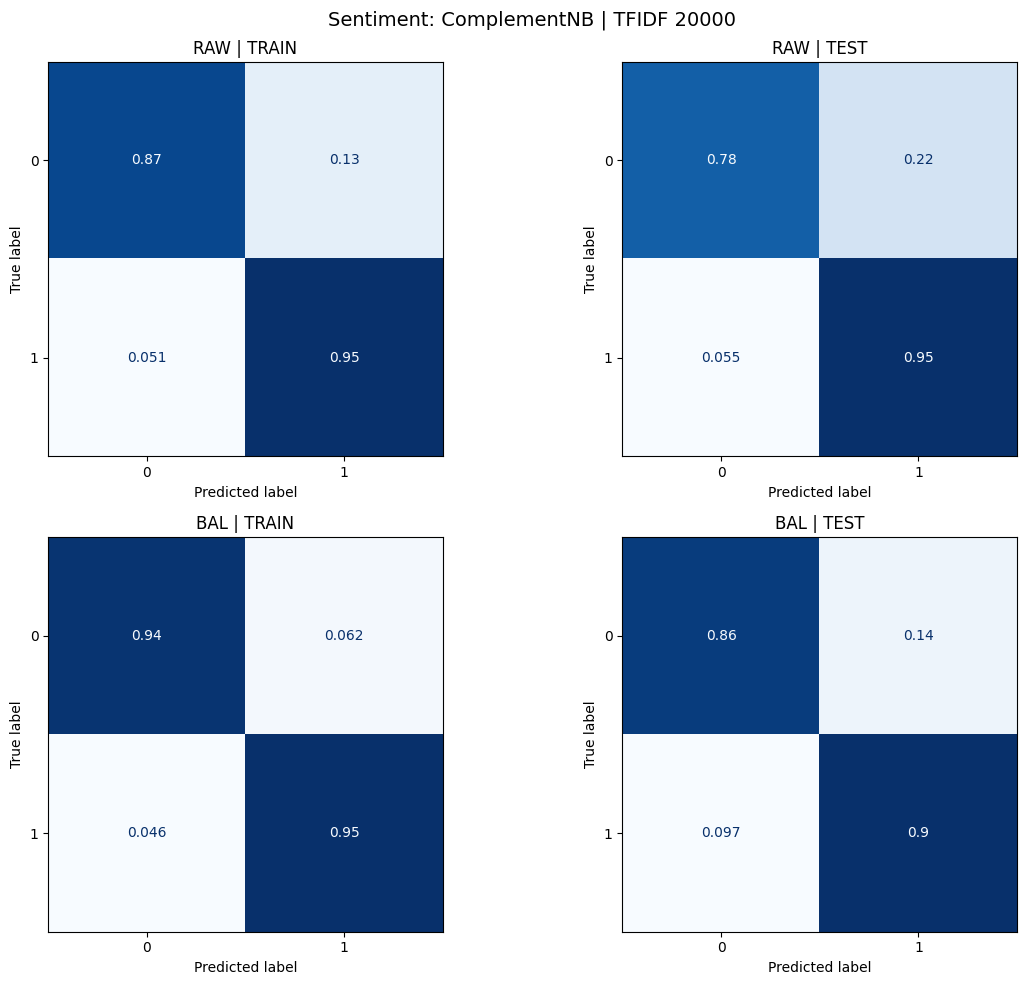


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           0       0.76      0.87      0.81      5772
           1       0.98      0.95      0.96     31227

    accuracy                           0.94     36999
   macro avg       0.87      0.91      0.89     36999
weighted avg       0.94      0.94      0.94     36999


--- RAW | TEST report ---
              precision    recall  f1-score   support

           0       0.73      0.78      0.75      1443
           1       0.96      0.95      0.95      7807

    accuracy                           0.92      9250
   macro avg       0.84      0.86      0.85      9250
weighted avg       0.92      0.92      0.92      9250


--- BAL | TRAIN report ---
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      5772
           1       0.94      0.95      0.95      5772

    accuracy                           0.95     11544
   macro avg       0.95      0.95      0.95  

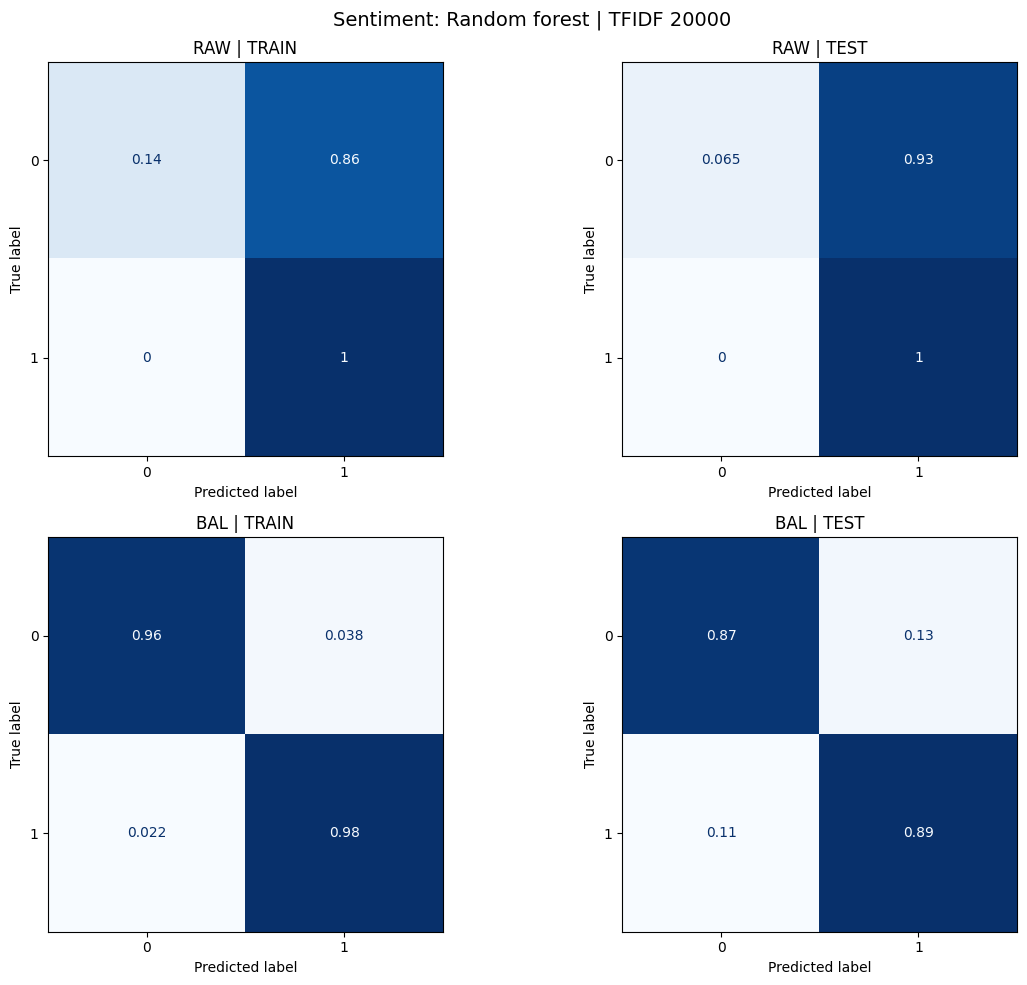


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           0       1.00      0.14      0.25      5772
           1       0.86      1.00      0.93     31227

    accuracy                           0.87     36999
   macro avg       0.93      0.57      0.59     36999
weighted avg       0.88      0.87      0.82     36999


--- RAW | TEST report ---
              precision    recall  f1-score   support

           0       1.00      0.07      0.12      1443
           1       0.85      1.00      0.92      7807

    accuracy                           0.85      9250
   macro avg       0.93      0.53      0.52      9250
weighted avg       0.88      0.85      0.80      9250


--- BAL | TRAIN report ---
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      5772
           1       0.96      0.98      0.97      5772

    accuracy                           0.97     11544
   macro avg       0.97      0.97      0.97  

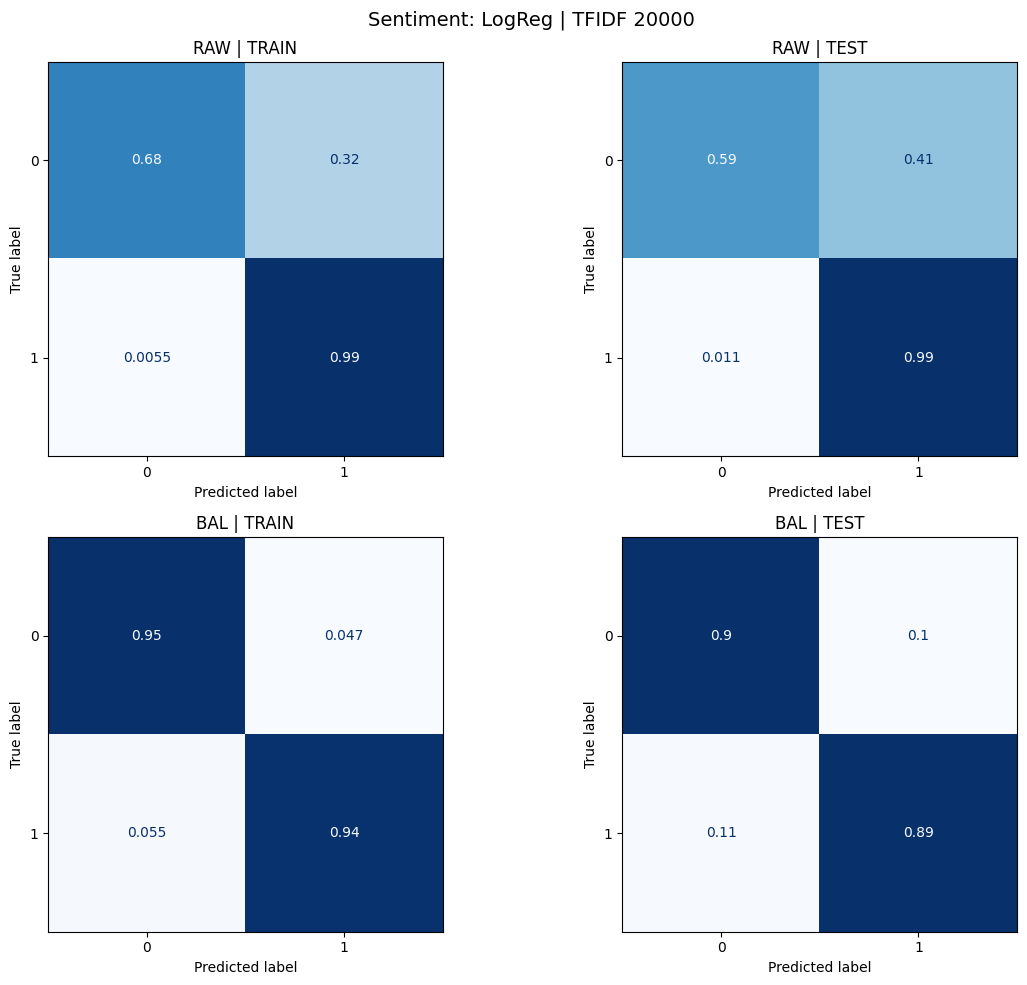


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           0       0.96      0.68      0.80      5772
           1       0.94      0.99      0.97     31227

    accuracy                           0.95     36999
   macro avg       0.95      0.84      0.88     36999
weighted avg       0.95      0.95      0.94     36999


--- RAW | TEST report ---
              precision    recall  f1-score   support

           0       0.91      0.59      0.72      1443
           1       0.93      0.99      0.96      7807

    accuracy                           0.93      9250
   macro avg       0.92      0.79      0.84      9250
weighted avg       0.93      0.93      0.92      9250


--- BAL | TRAIN report ---
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      5772
           1       0.95      0.94      0.95      5772

    accuracy                           0.95     11544
   macro avg       0.95      0.95      0.95  

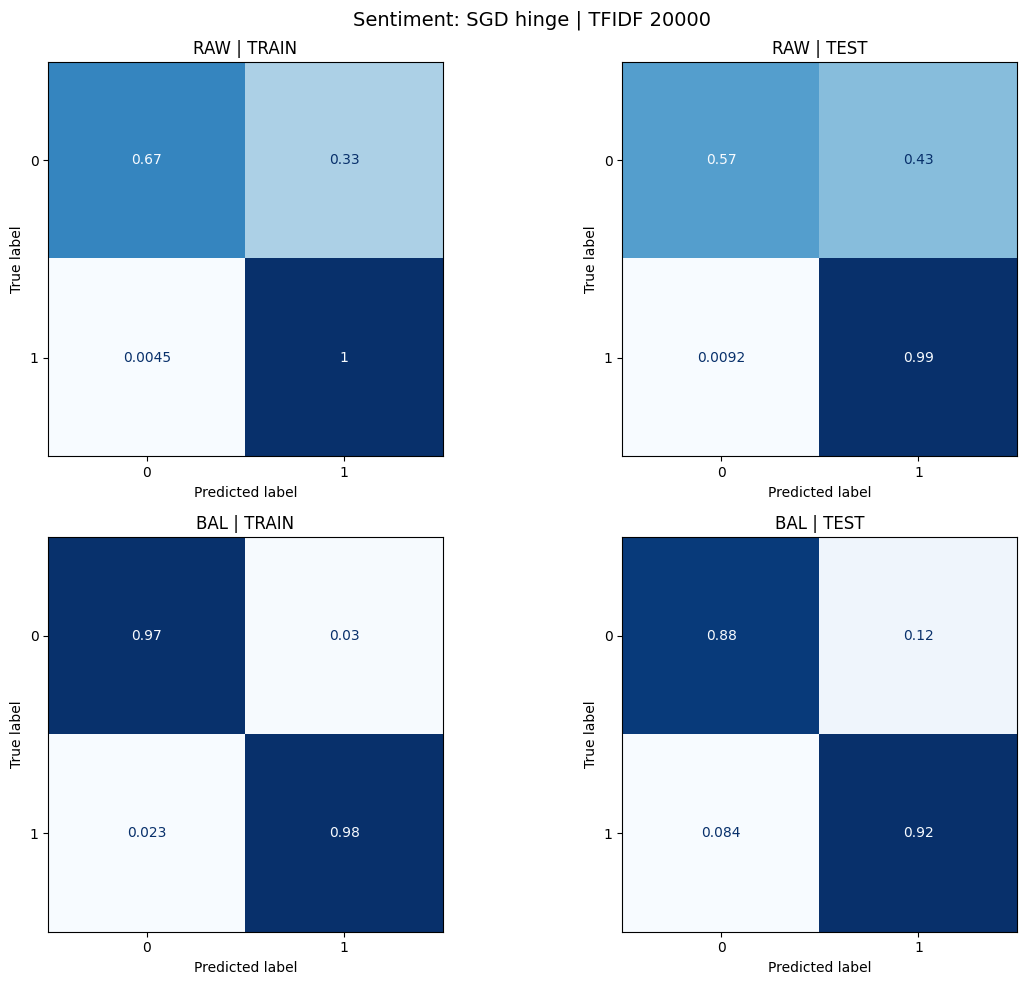


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           0       0.97      0.67      0.79      5772
           1       0.94      1.00      0.97     31227

    accuracy                           0.94     36999
   macro avg       0.95      0.83      0.88     36999
weighted avg       0.95      0.94      0.94     36999


--- RAW | TEST report ---
              precision    recall  f1-score   support

           0       0.92      0.57      0.70      1443
           1       0.93      0.99      0.96      7807

    accuracy                           0.92      9250
   macro avg       0.92      0.78      0.83      9250
weighted avg       0.92      0.92      0.92      9250


--- BAL | TRAIN report ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      5772
           1       0.97      0.98      0.97      5772

    accuracy                           0.97     11544
   macro avg       0.97      0.97      0.97  

In [18]:
chosen_models = ["LinearSVC", "ComplementNB", "Random forest","LogReg","SGD hinge"]

for m in chosen_models:
    show_cm_raw_vs_bal_for_model(
        model_name=m,
        max_features=20000,
        X_train=X_train, y_train=y_train,
        X_train_bal=X_train_bal, y_train_bal=y_train_bal,
        X_test=X_test, y_test=y_test,
        title_prefix="Sentiment",
    )

In [19]:
X_text = data_sent["cleaned_full"]
y_text = data_sent["Sentiment"].astype(int)

X_train_tx, X_test_tx, y_train_tx, y_test_tx = train_test_split(
    X_text, y_text, test_size=0.2, stratify=y_text, random_state=42
)

In [20]:
train_df1 = pd.DataFrame({
    "cleaned_full": X_train_tx,
    "Sentiment": y_train_tx
})

min_count = train_df1["Sentiment"].value_counts().min()

train_bal_tx = (
    train_df1.groupby("Sentiment", group_keys=False)
    .apply(lambda g: g.sample(min_count, random_state=42))
    .sample(frac=1, random_state=42) 
)

X_train_bal_tx = train_bal_tx["cleaned_full"]
y_train_bal_tx = train_bal_tx["Sentiment"]

In [21]:
def make_preprocessor_text(max_features=20000):
    return TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1,2),
        min_df=2
    )

In [22]:
def run_block_text(Xtr, Xte, ytr, yte, dataset_label, max_features):
    pre = make_preprocessor_text(max_features=max_features)
    rows = []

    tfidf_name = "TFIDF_10k" if max_features == 10000 else "TFIDF_20k"
    print(f"\n=== Dataset: {dataset_label} | TFIDF: {max_features} ===")

    for name, model in models.items():
        print(f"Trening modela: {name} ...")

        pipe = Pipeline([
            ("pre", pre),
            ("clf",clone( model))
        ])

        pipe.fit(Xtr, ytr)
        pred = pipe.predict(Xte)

        acc = accuracy_score(yte, pred)
        f1m = f1_score(yte, pred, average="macro")
        f1w = f1_score(yte, pred, average="weighted")

        rows.append({
            "Dataset": dataset_label,
            "TFIDF": tfidf_name,
            "Model": name,
            "Accuracy": acc,
            "F1_macro": f1m,
            "F1_weighted": f1w,
        })

        print(f"done | Acc={acc:.4f} | F1_macro={f1m:.4f} | F1_weighted={f1w:.4f}")

    return rows

In [23]:
rows1 = []
for k in [10000, 20000]:
    rows1 += run_block_text(X_train_tx ,X_test_tx, y_train_tx, y_test_tx, "RAW", k)
    rows1 += run_block_text(X_train_bal_tx, X_test_tx, y_train_bal_tx, y_test_tx, "BAL", k)

results_df1 = pd.DataFrame(rows1).sort_values("F1_macro", ascending=False)
results_df1


=== Dataset: RAW | TFIDF: 10000 ===
Trening modela: LinearSVC ...
done | Acc=0.9378 | F1_macro=0.8754 | F1_weighted=0.9361
Trening modela: SGD hinge ...
done | Acc=0.9251 | F1_macro=0.8310 | F1_weighted=0.9178
Trening modela: LogReg ...
done | Acc=0.9284 | F1_macro=0.8422 | F1_weighted=0.9225
Trening modela: Random forest ...
done | Acc=0.8597 | F1_macro=0.5529 | F1_weighted=0.8077
Trening modela: ComplementNB ...
done | Acc=0.8956 | F1_macro=0.8270 | F1_weighted=0.9019

=== Dataset: BAL | TFIDF: 10000 ===
Trening modela: LinearSVC ...
done | Acc=0.8971 | F1_macro=0.8339 | F1_weighted=0.9044
Trening modela: SGD hinge ...
done | Acc=0.8941 | F1_macro=0.8296 | F1_weighted=0.9017
Trening modela: LogReg ...
done | Acc=0.8888 | F1_macro=0.8234 | F1_weighted=0.8973
Trening modela: Random forest ...
done | Acc=0.8671 | F1_macro=0.7922 | F1_weighted=0.8781
Trening modela: ComplementNB ...
done | Acc=0.8952 | F1_macro=0.8285 | F1_weighted=0.9021

=== Dataset: RAW | TFIDF: 20000 ===
Trening mod

,Dataset,TFIDF,Model,Accuracy,F1_macro,F1_weighted
0,RAW,TFIDF_10k,LinearSVC,0.937838,0.875361,0.936073
10,RAW,TFIDF_20k,LinearSVC,0.937838,0.875207,0.936031
14,RAW,TFIDF_20k,ComplementNB,0.922486,0.857639,0.923743
2,RAW,TFIDF_10k,LogReg,0.928432,0.842195,0.922455
12,RAW,TFIDF_20k,LogReg,0.927568,0.838693,0.921070
15,BAL,TFIDF_20k,LinearSVC,0.900432,0.838330,0.907268
16,BAL,TFIDF_20k,SGD hinge,0.899135,0.836508,0.906125
5,BAL,TFIDF_10k,LinearSVC,0.897081,0.833862,0.904371
1,RAW,TFIDF_10k,SGD hinge,0.925081,0.831037,0.917763
6,BAL,TFIDF_10k,SGD hinge,0.894054,0.829635,0.901710


In [24]:
def show_cm_raw_vs_bal_for_model_tx(
    model_name,
    max_features,
    X_train, y_train,
    X_train_bal, y_train_bal,
    X_test, y_test,
    title_prefix="SCORE",
    normalize="true"

):
        
    pre = make_preprocessor_text(max_features=max_features)

    print("="*90)
    print(f"{title_prefix} | Model: {model_name} | TFIDF: {max_features}")
    print("="*90)

    pipe_raw = Pipeline([("pre", pre), ("clf", clone(models[model_name]))])
    pipe_raw.fit(X_train, y_train)

    pred_raw_tr = pipe_raw.predict(X_train)
    pred_raw_te = pipe_raw.predict(X_test)

    cm_raw_tr = confusion_matrix(y_train, pred_raw_tr, normalize=normalize)
    cm_raw_te = confusion_matrix(y_test,  pred_raw_te, normalize=normalize)

    pipe_bal = Pipeline([("pre", pre), ("clf", models[model_name])])
    pipe_bal.fit(X_train_bal, y_train_bal)

    pred_bal_tr = pipe_bal.predict(X_train_bal)
    pred_bal_te = pipe_bal.predict(X_test)

    cm_bal_tr = confusion_matrix(y_train_bal, pred_bal_tr,  normalize=normalize)
    cm_bal_te = confusion_matrix(y_test,      pred_bal_te,  normalize=normalize)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    ConfusionMatrixDisplay(cm_raw_tr).plot(ax=axes[0,0], cmap="Blues", colorbar=False)
    axes[0,0].set_title("RAW | TRAIN")
    axes[0,0].grid(False)

    ConfusionMatrixDisplay(cm_raw_te).plot(ax=axes[0,1], cmap="Blues", colorbar=False)
    axes[0,1].set_title("RAW | TEST")
    axes[0,1].grid(False)

    ConfusionMatrixDisplay(cm_bal_tr).plot(ax=axes[1,0], cmap="Blues", colorbar=False)
    axes[1,0].set_title("BAL | TRAIN")
    axes[1,0].grid(False)

    ConfusionMatrixDisplay(cm_bal_te).plot(ax=axes[1,1], cmap="Blues", colorbar=False)
    axes[1,1].set_title("BAL | TEST")
    axes[1,1].grid(False)

    plt.suptitle(f"{title_prefix}: {model_name} | TFIDF {max_features}", fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\n--- RAW | TRAIN report ---")
    print(classification_report(y_train, pred_raw_tr))

    print("\n--- RAW | TEST report ---")
    print(classification_report(y_test, pred_raw_te))

    print("\n--- BAL | TRAIN report ---")
    print(classification_report(y_train_bal, pred_bal_tr))

    print("\n--- BAL | TEST report ---")
    print(classification_report(y_test, pred_bal_te))

Sentiment Text | Model: LinearSVC | TFIDF: 20000


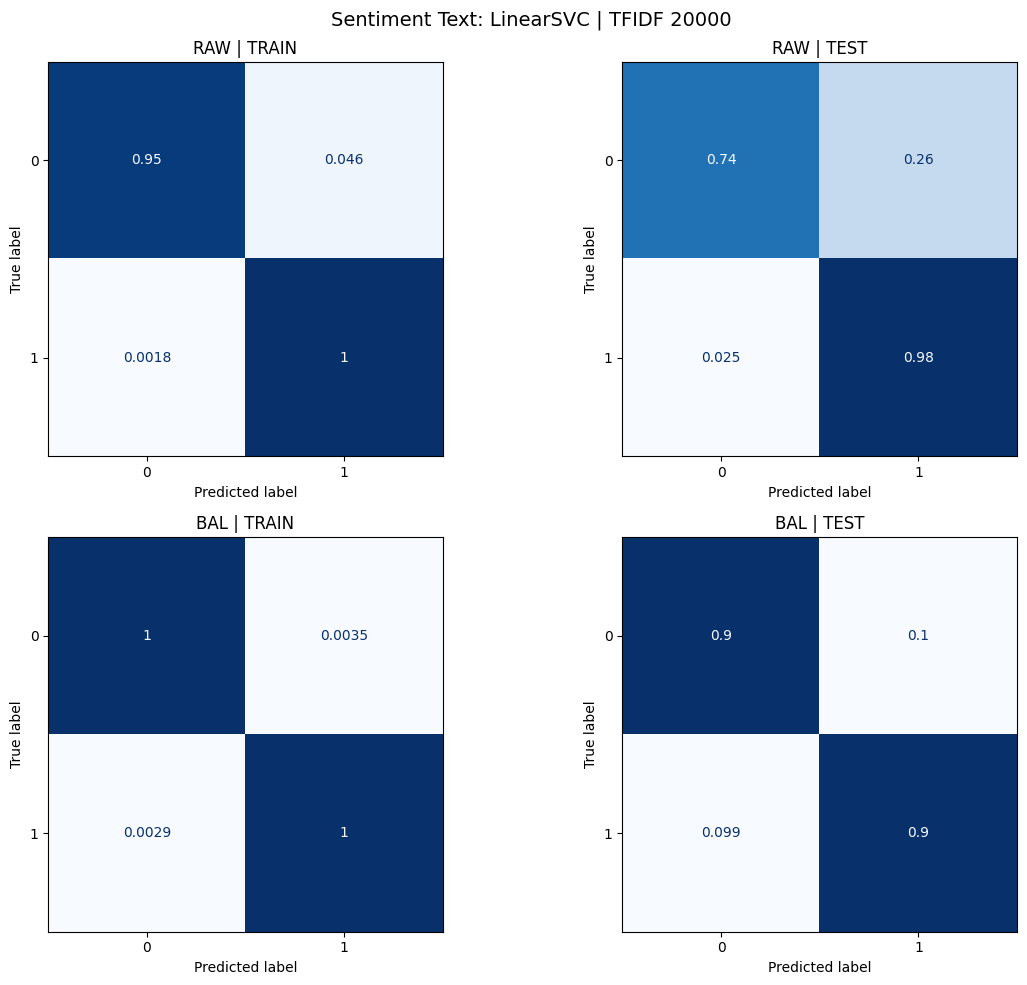


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      5772
           1       0.99      1.00      0.99     31227

    accuracy                           0.99     36999
   macro avg       0.99      0.98      0.98     36999
weighted avg       0.99      0.99      0.99     36999


--- RAW | TEST report ---
              precision    recall  f1-score   support

           0       0.85      0.74      0.79      1443
           1       0.95      0.98      0.96      7807

    accuracy                           0.94      9250
   macro avg       0.90      0.86      0.88      9250
weighted avg       0.94      0.94      0.94      9250


--- BAL | TRAIN report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5772
           1       1.00      1.00      1.00      5772

    accuracy                           1.00     11544
   macro avg       1.00      1.00      1.00  

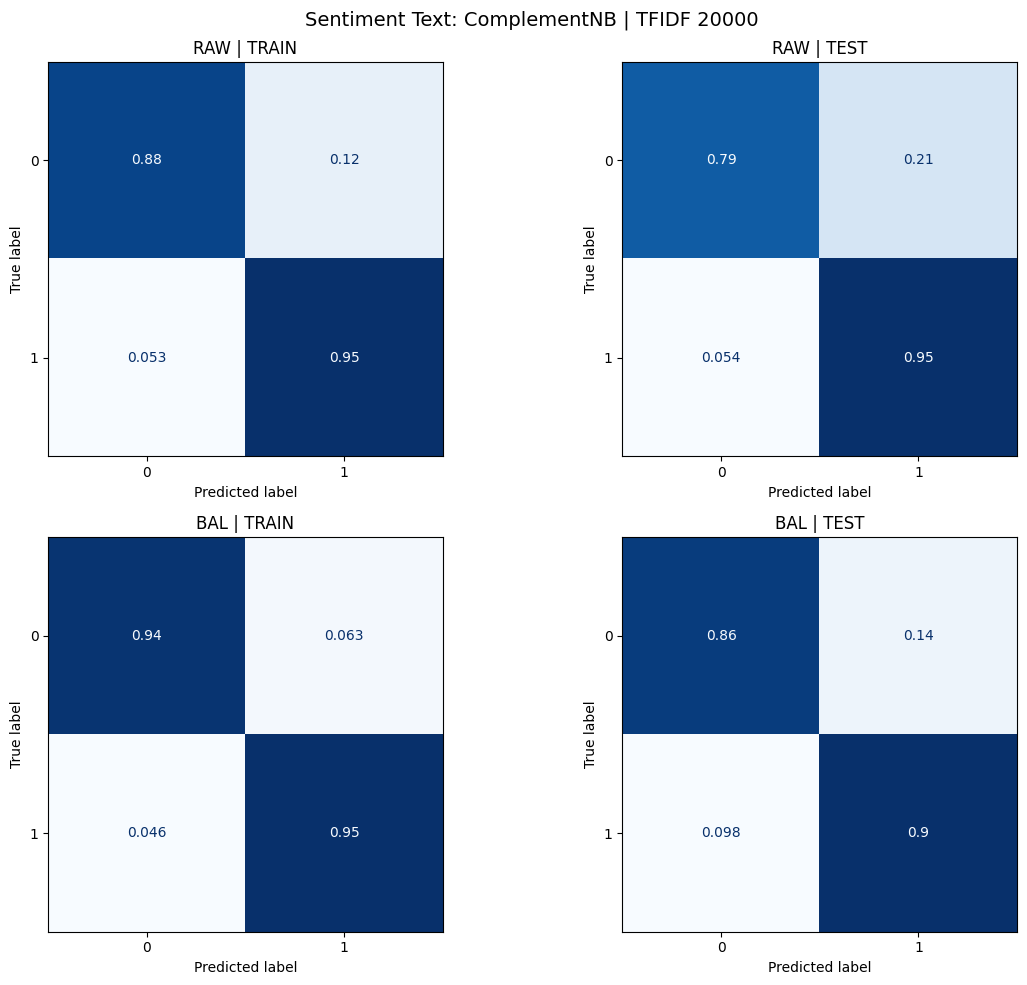


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           0       0.75      0.88      0.81      5772
           1       0.98      0.95      0.96     31227

    accuracy                           0.94     36999
   macro avg       0.87      0.91      0.89     36999
weighted avg       0.94      0.94      0.94     36999


--- RAW | TEST report ---
              precision    recall  f1-score   support

           0       0.73      0.79      0.76      1443
           1       0.96      0.95      0.95      7807

    accuracy                           0.92      9250
   macro avg       0.85      0.87      0.86      9250
weighted avg       0.93      0.92      0.92      9250


--- BAL | TRAIN report ---
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      5772
           1       0.94      0.95      0.95      5772

    accuracy                           0.95     11544
   macro avg       0.95      0.95      0.95  

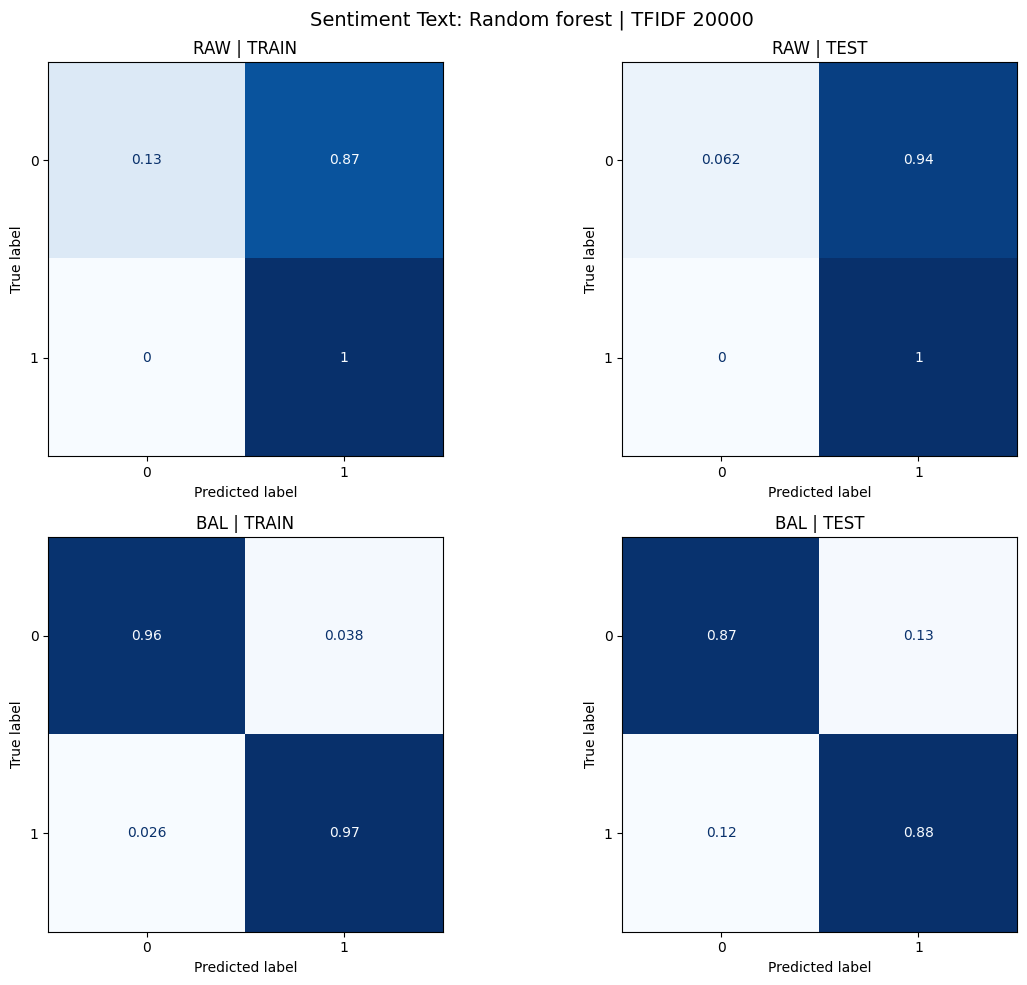


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           0       1.00      0.13      0.24      5772
           1       0.86      1.00      0.93     31227

    accuracy                           0.86     36999
   macro avg       0.93      0.57      0.58     36999
weighted avg       0.88      0.86      0.82     36999


--- RAW | TEST report ---
              precision    recall  f1-score   support

           0       1.00      0.06      0.12      1443
           1       0.85      1.00      0.92      7807

    accuracy                           0.85      9250
   macro avg       0.93      0.53      0.52      9250
weighted avg       0.88      0.85      0.80      9250


--- BAL | TRAIN report ---
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      5772
           1       0.96      0.97      0.97      5772

    accuracy                           0.97     11544
   macro avg       0.97      0.97      0.97  

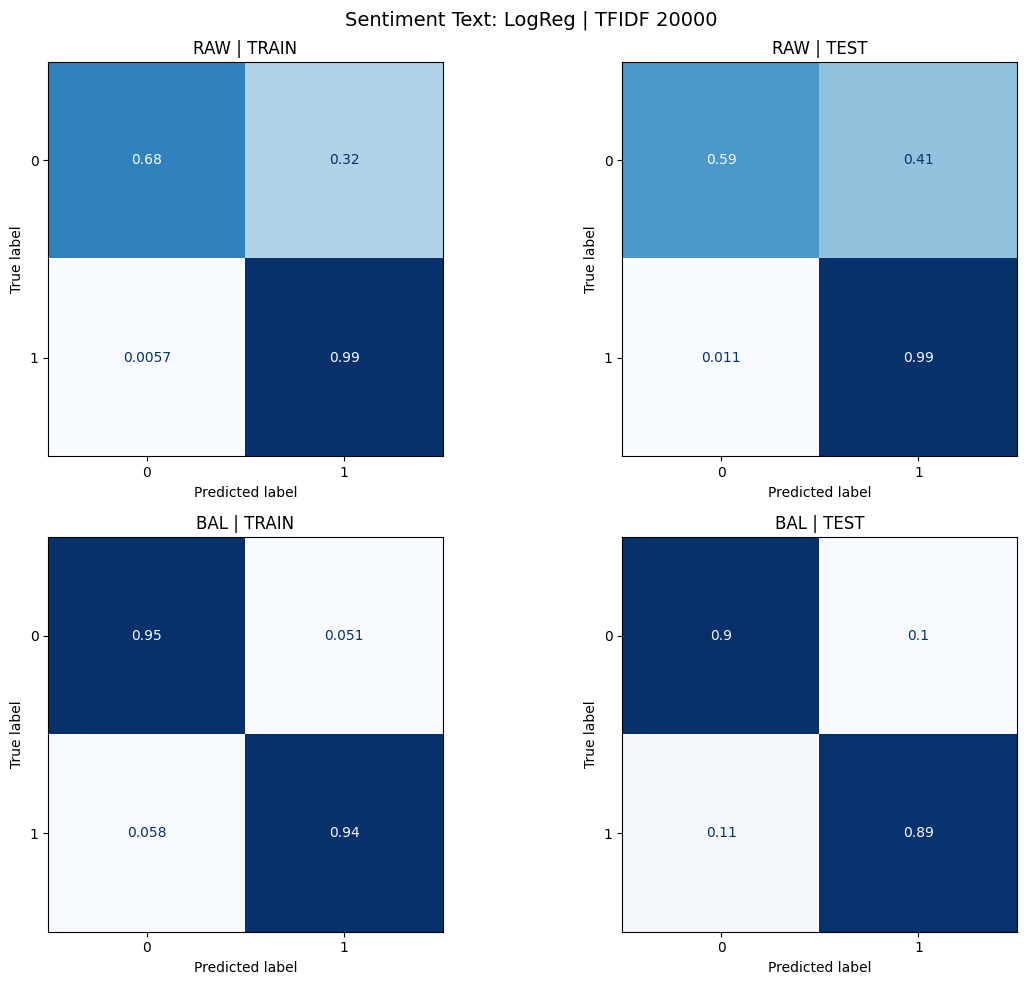


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           0       0.96      0.68      0.80      5772
           1       0.94      0.99      0.97     31227

    accuracy                           0.95     36999
   macro avg       0.95      0.84      0.88     36999
weighted avg       0.95      0.95      0.94     36999


--- RAW | TEST report ---
              precision    recall  f1-score   support

           0       0.91      0.59      0.72      1443
           1       0.93      0.99      0.96      7807

    accuracy                           0.93      9250
   macro avg       0.92      0.79      0.84      9250
weighted avg       0.93      0.93      0.92      9250


--- BAL | TRAIN report ---
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      5772
           1       0.95      0.94      0.95      5772

    accuracy                           0.95     11544
   macro avg       0.95      0.95      0.95  

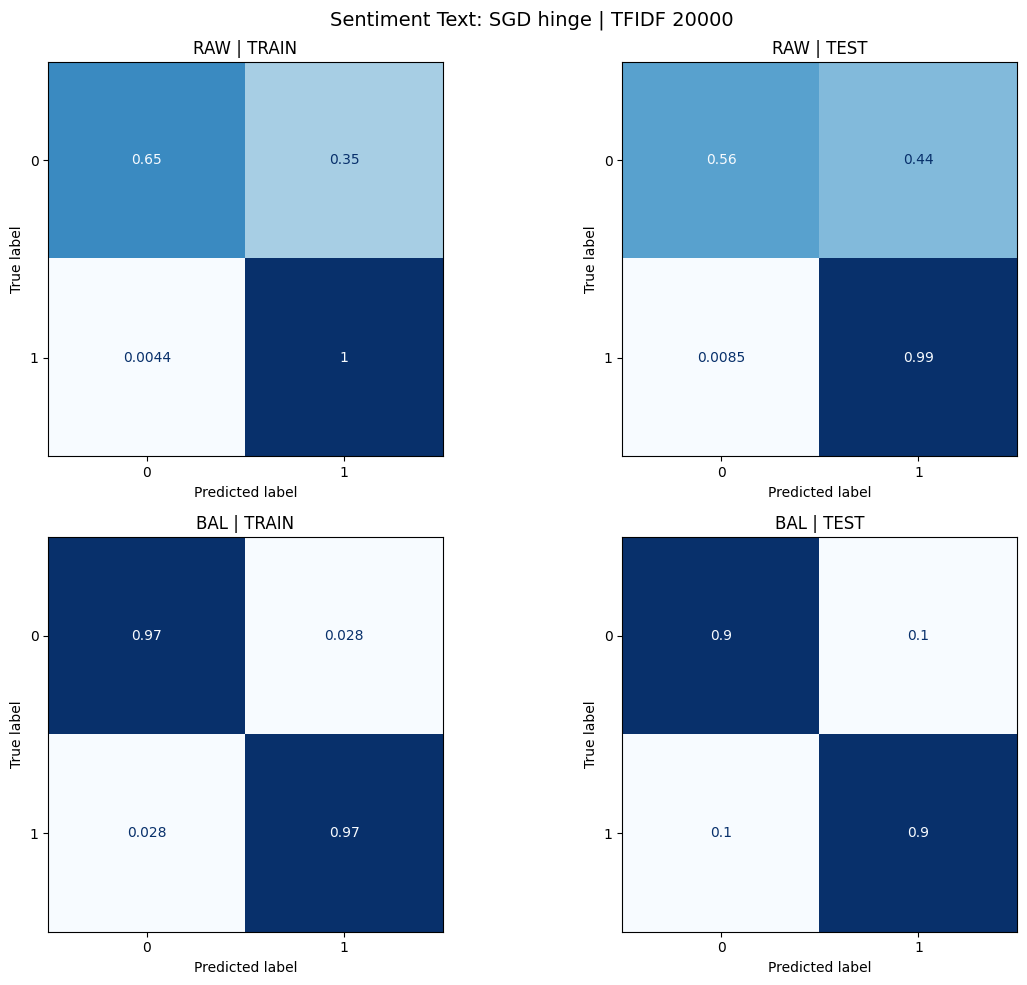


--- RAW | TRAIN report ---
              precision    recall  f1-score   support

           0       0.96      0.65      0.78      5772
           1       0.94      1.00      0.97     31227

    accuracy                           0.94     36999
   macro avg       0.95      0.82      0.87     36999
weighted avg       0.94      0.94      0.94     36999


--- RAW | TEST report ---
              precision    recall  f1-score   support

           0       0.92      0.56      0.69      1443
           1       0.92      0.99      0.96      7807

    accuracy                           0.92      9250
   macro avg       0.92      0.77      0.83      9250
weighted avg       0.92      0.92      0.92      9250


--- BAL | TRAIN report ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      5772
           1       0.97      0.97      0.97      5772

    accuracy                           0.97     11544
   macro avg       0.97      0.97      0.97  

In [25]:
chosen_models = ["LinearSVC", "ComplementNB", "Random forest","LogReg","SGD hinge"]

for m in chosen_models:
    show_cm_raw_vs_bal_for_model_tx(
        model_name=m,
        max_features=20000,
        X_train=X_train_tx, y_train=y_train_tx,
        X_train_bal=X_train_bal_tx, y_train_bal=y_train_bal_tx,
        X_test=X_test_tx, y_test=y_test_tx,
        title_prefix="Sentiment Text",
    )

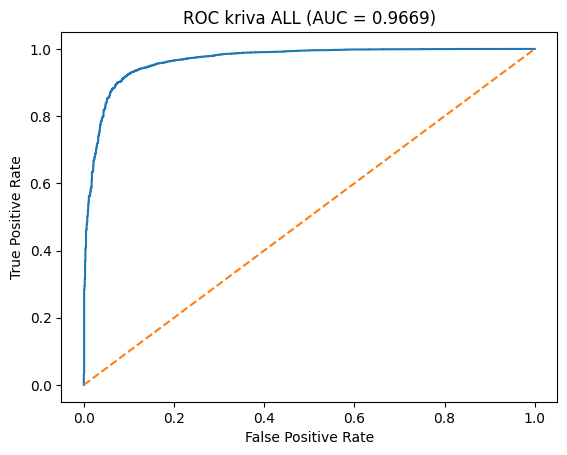

AUC: 0.9669


In [27]:

pre = make_preprocessor(max_features=20000)

model = clone(models["LinearSVC"])   

pipe = Pipeline([
    ("pre", pre),
    ("clf", model)
])

pipe.fit(X_train, y_train)

if hasattr(pipe, "predict_proba"):
    y_score = pipe.predict_proba(X_test)[:, 1]
else:
    y_score = pipe.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_score)
auc = roc_auc_score(y_test, y_score)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC kriva ALL (AUC = {auc:.4f})")
plt.show()

print(f"AUC: {auc:.4f}")

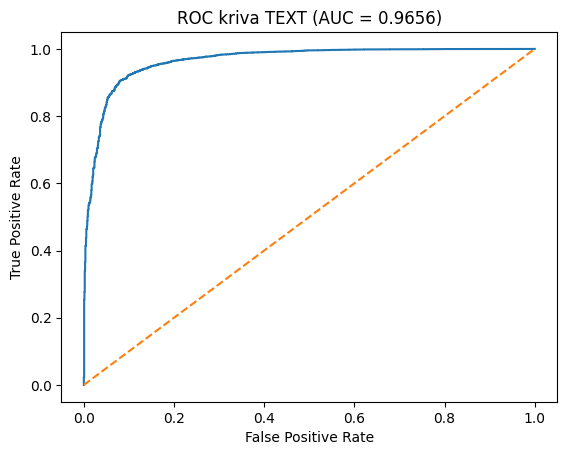

AUC: 0.9656


In [28]:
pre = make_preprocessor_text(max_features=20000)

model = clone(models["LinearSVC"])   

pipe = Pipeline([
    ("pre", pre),
    ("clf", (model))
])

pipe.fit(X_train_tx, y_train_tx)

if hasattr(pipe, "predict_proba"):
    y_score = pipe.predict_proba(X_test_tx)[:, 1]
else:
    y_score = pipe.decision_function(X_test_tx)

fpr, tpr, _ = roc_curve(y_test_tx, y_score)
auc = roc_auc_score(y_test_tx, y_score)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC kriva TEXT (AUC = {auc:.4f})")
plt.show()

print(f"AUC: {auc:.4f}")